<a href="https://colab.research.google.com/github/soulqan/PCVK_GANJIL_2025/blob/main/WEEK_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

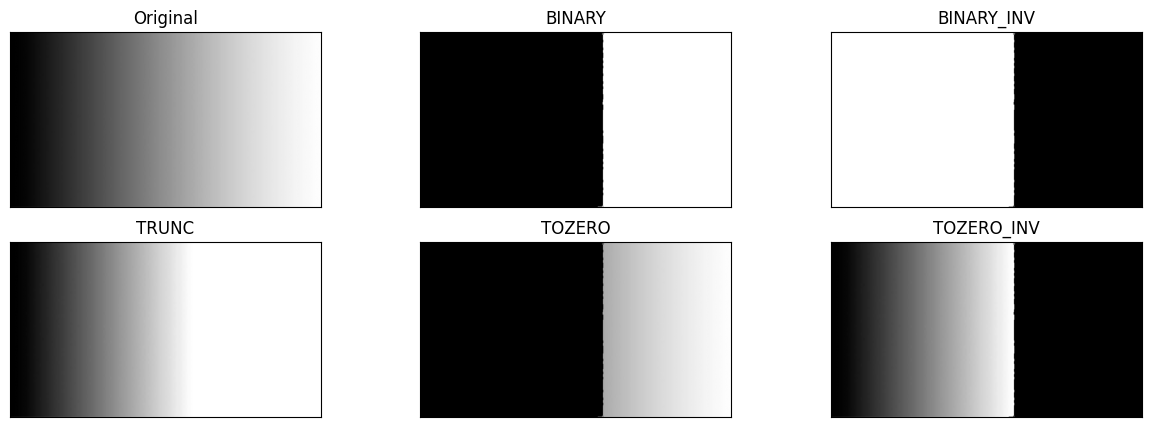

In [4]:
img = cv2.imread('/content/drive/MyDrive/images/gradient.jpg', 0)

# Nilai threshold yang digunakan
thresh = 170

# 5 jenis threshold global
ret, th1 = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY)
ret, th2 = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY_INV)
ret, th3 = cv2.threshold(img, thresh, 255, cv2.THRESH_TRUNC)
ret, th4 = cv2.threshold(img, thresh, 255, cv2.THRESH_TOZERO)
ret, th5 = cv2.threshold(img, thresh, 255, cv2.THRESH_TOZERO_INV)

titles = ['Original', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, th1, th2, th3, th4, th5]

plt.figure(figsize=(15,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


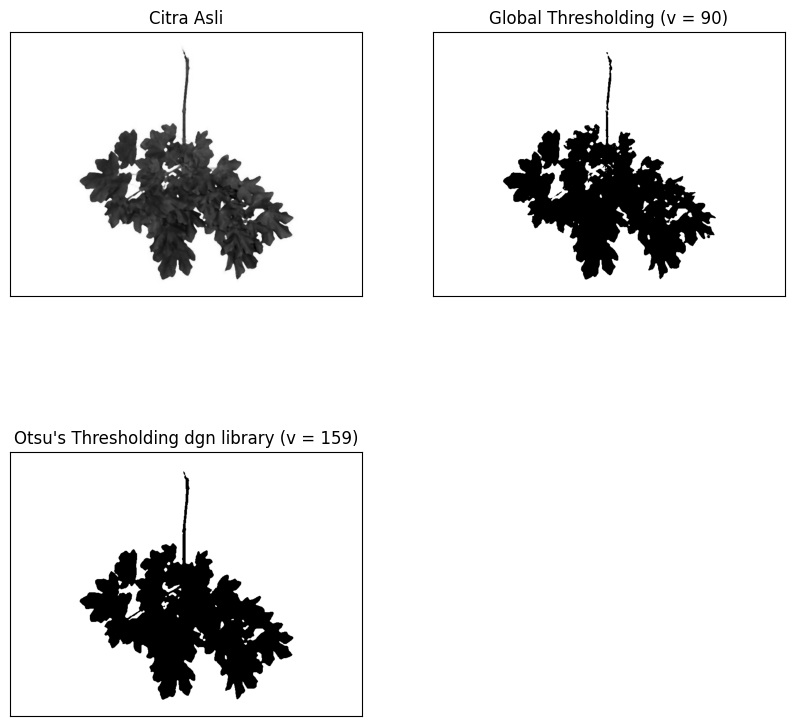

In [10]:
# Membaca gambar grayscale
path ='/content/drive/MyDrive/images/leaves.jpg'

# Preprocessing: median blur untuk mengurangi noise
citra = cv2.medianBlur(cv2.imread(path), 5)

# Ubah ke grayscale
gray = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY)
# Jika ingin, bisa aktifkan blur tambahan:
# gray = cv2.medianBlur(gray,5)

# Global threshold manual (v = 90)
thresh = 90
ret, th1 = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)

# Otsu threshold otomatis (tanpa menentukan T manual)
ret2, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Tampilkan hasil
x = "Otsu's Thresholding dgn library (v = " + str(int(ret2)) + ")"
titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra2 = [gray, th1, th2]

plt.figure(figsize=(10,10))
for i in range(len(citra2)):
    plt.subplot(2,2,i+1)
    plt.imshow(citra2[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

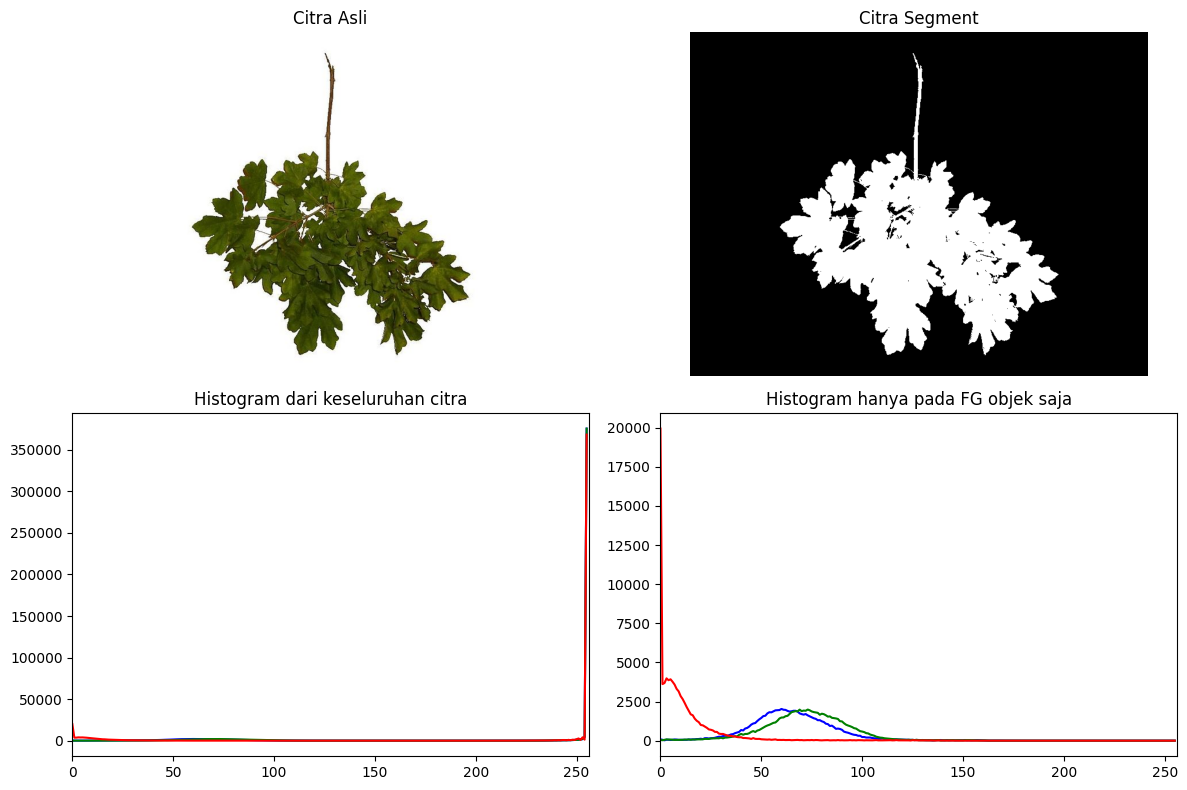

In [19]:
# Membaca gambar dan konversi
filename = '/content/drive/MyDrive/images/leaves.jpg'
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Threshold invers + Otsu (agar objek foreground putih pada mask)
_, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Segmentasi menggunakan operasi bitwise
segment = cv2.bitwise_and(img, img, mask=mask)

# Warna channel (R, G, B)
colors = ('b', 'g', 'r')

# Visualisasi hasil
plt.figure(figsize=(12,8))

# Citra asli
plt.subplot(2,2,1)
plt.imshow(img)
plt.title("Citra Asli")
plt.axis('off')

# Citra segmentasi (mask)
plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Citra Segment")
plt.axis('off')

# Histogram keseluruhan citra
plt.subplot(2,2,3)
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color=col)
plt.title("Histogram dari keseluruhan citra")
plt.xlim([0,256])

# Histogram foreground saja
plt.subplot(2,2,4)
for i, col in enumerate(colors):
    hist_fg = cv2.calcHist([img], [i], mask, [256], [0,256])
    plt.plot(hist_fg, color=col)
plt.title("Histogram hanya pada FG objek saja")
plt.xlim([0,256])

plt.tight_layout()
plt.show()

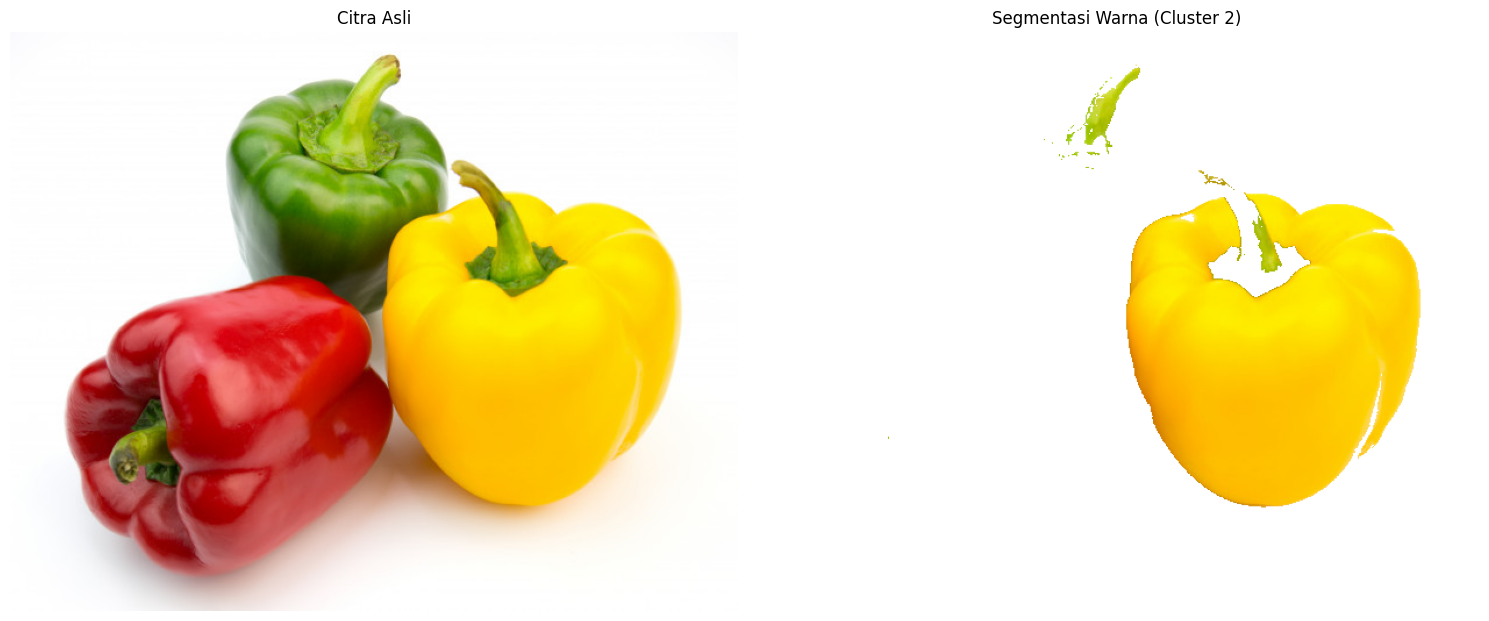

In [21]:
filename = '/content/drive/MyDrive/images/peppers.jpg'
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ubah menjadi array 2D (setiap pixel jadi 1 baris dengan 3 nilai RGB)
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Kriteria K-Means (berhenti jika konvergen atau iterasi >= 100)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Jumlah cluster (gunakan 5 biar warna lebih terpisah)
k = 5
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Konversi ke integer dan reshape
centers = np.uint8(centers)
labels = labels.flatten()

# Rekonstruksi citra hasil segmentasi penuh
segmented_image = centers[labels]
segmented_image = segmented_image.reshape(img.shape)

# Pilih cluster warna yang ingin ditampilkan (misal: kuning)
selected_cluster = 2  # ubah sesuai hasil clustering

# Buat mask: True untuk area cluster terpilih
mask = (labels == selected_cluster)
mask = mask.reshape(img.shape[:2])

# Buat citra hasil isolasi: area lain diubah jadi putih
isolated = np.ones_like(img) * 255
isolated[mask] = img[mask]

# Visualisasi hasil
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(isolated)
plt.title(f'Segmentasi Warna (Cluster {selected_cluster})')
plt.axis('off')

plt.tight_layout()
plt.show()

# Kendala yang Dihadapi

Kendala yang muncul adalah bagian tangkai hijau ikut terdeteksi sebagai warna kuning.
Hal ini terjadi karena warna hijau muda pada tangkai memiliki nilai RGB yang mirip dengan warna kuning, sehingga K-Means menempatkannya dalam cluster yang sama.
Selain itu, pantulan cahaya pada permukaan paprika juga membuat sebagian area kuning memiliki variasi intensitas yang menyebabkan batas warnanya tidak sempurna.

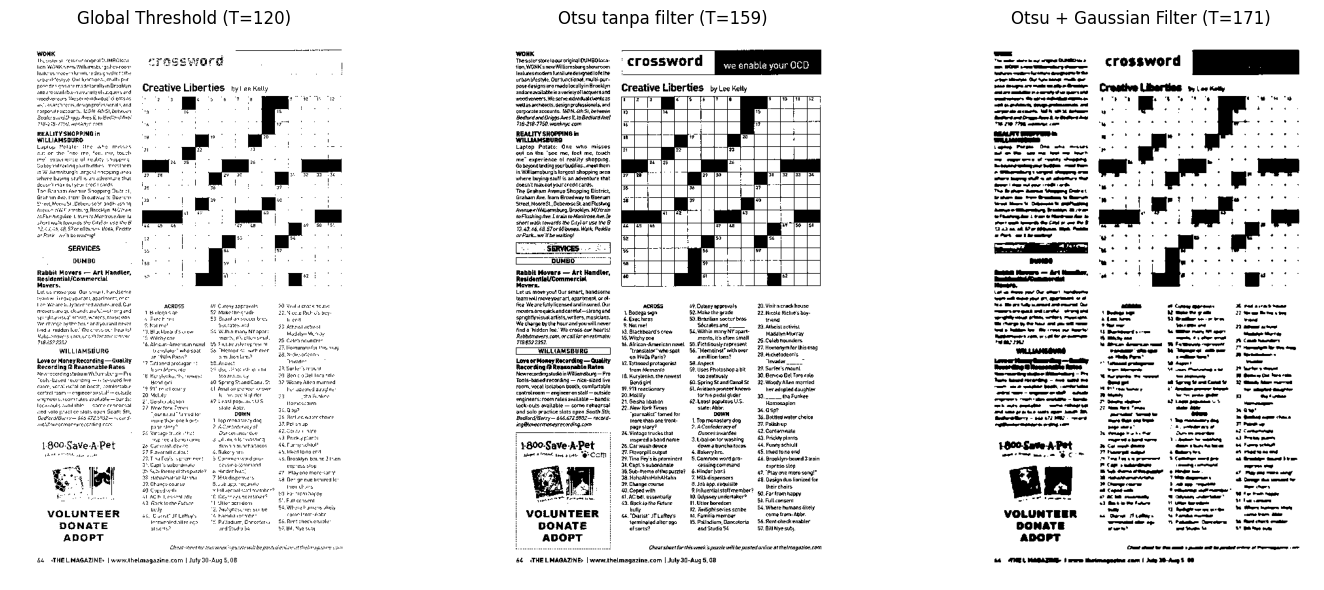

In [24]:
# Membaca gambar dalam mode grayscale
filename = '/content/drive/MyDrive/images/crossword.jpg'
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# --- 1. Global Threshold ---
ret1, th1 = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

# --- 2. Otsu Threshold tanpa filtering ---
ret2, th2 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- 3. Otsu Threshold dengan Gaussian filtering (hasil biasanya lebih halus) ---
blur = cv2.GaussianBlur(img, (5,5), 0)
ret3, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Visualisasi hasil
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
plt.imshow(th1, cmap='gray')
plt.title('Global Threshold (T=120)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(th2, cmap='gray')
plt.title(f"Otsu tanpa filter (T={ret2:.0f})")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(th3, cmap='gray')
plt.title(f"Otsu + Gaussian Filter (T={ret3:.0f})")
plt.axis('off')

plt.tight_layout()
plt.show()

Otsu + Gaussian Filter: hasil paling bersih dan kontras jelas antara kotak putih dan hitam.